In [2]:
!pip install -q dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 5.1 MB/s eta 0:00:00


# **Random Forest Classification**

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [4]:
# Load data
df = pd.read_csv("iris_2D.csv")

In [5]:
df

,Petal_Length,Petal_Width,Label
0,1.0,0.2,0.0
1,1.3,0.6,0.0
2,0.9,0.7,0.0
3,1.7,0.5,1.0
4,1.8,0.9,1.0
5,1.2,1.3,1.0


In [8]:
# Get data
x_data = df[["Petal_Length", "Petal_Width"]].to_numpy()
y_data = df["Label"].to_numpy(dtype=np.uint8)

In [9]:
# Define Model
rf_classifier = RandomForestClassifier(
    n_estimators=3, # Số lượng decision tree sẽ xử dụng
    max_features=1, # Số lượng feature tối đa khi lấy sampling
    max_depth=1,    # Độ xâu của cây
    criterion='entropy', # Tiêu chí xây dựng tree
    max_samples=6        # Tối đa mỗi một cây 6 sample
)

In [10]:
rf_classifier.fit(x_data, y_data)

RandomForestClassifier(criterion='entropy', max_depth=1, max_features=1,
                       max_samples=6, n_estimators=3)

In [12]:
# Predict
x_test = np.array([[2.7, 0.8]])
y_predicted = rf_classifier.predict(x_test)
print(y_predicted)

[1]


In [15]:
rf_classifier.estimators_

[DecisionTreeClassifier(criterion='entropy', max_depth=1, max_features=1,
                        random_state=2019651750),
 DecisionTreeClassifier(criterion='entropy', max_depth=1, max_features=1,
                        random_state=759877271),
 DecisionTreeClassifier(criterion='entropy', max_depth=1, max_features=1,
                        random_state=39139826)]

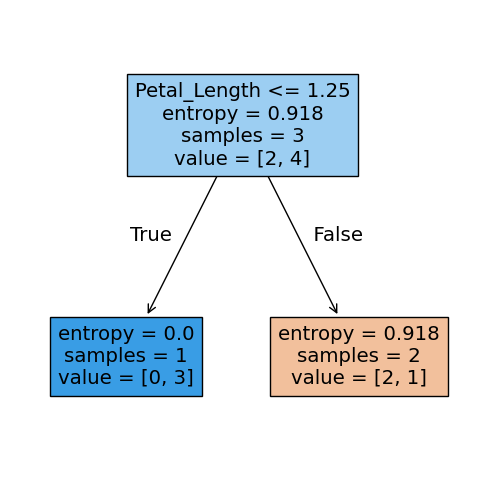

In [16]:
# Visualize
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
_ = tree.plot_tree(
    rf_classifier.estimators_[0],
    feature_names=['Petal_Length', 'Petal_Width'],
    filled=True
)

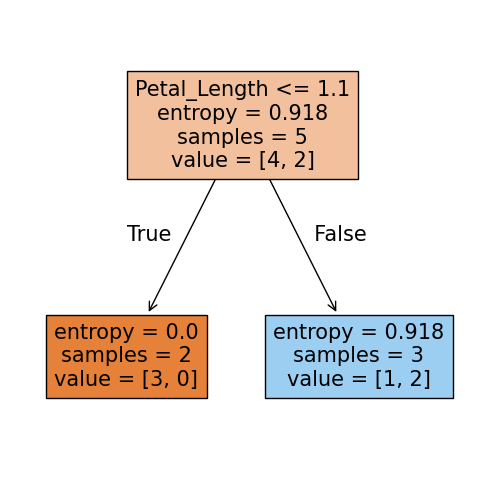

In [17]:
# Visualize
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
_ = tree.plot_tree(
    rf_classifier.estimators_[1],
    feature_names=['Petal_Length', 'Petal_Width'],
    filled=True
)

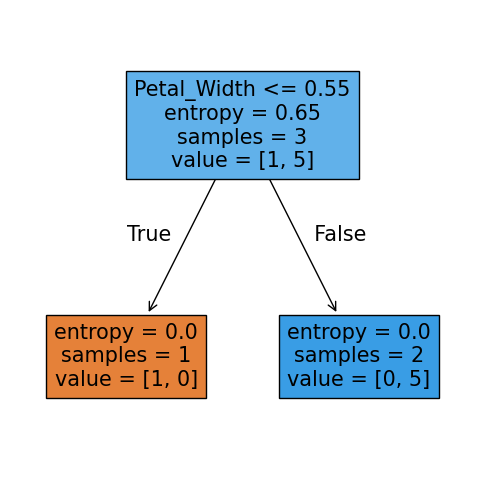

In [18]:
# Visualize
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
_ = tree.plot_tree(
    rf_classifier.estimators_[2],
    feature_names=['Petal_Length', 'Petal_Width'],
    filled=True
)

# **Random Forest for Regression**

In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

In [20]:
# Load data
df = pd.read_csv('Salary_Data.csv')
df = df.sample(n = 4)

In [21]:
df

,Experience,Salary
4,3.0,60.0
0,1.0,0.0
7,4.5,61.0
11,6.5,91.0


In [22]:
# Get data
x_data = df.iloc[:, :-1]
y_data = df.iloc[:, -1]

In [28]:
# Define Model
rf_regressor = RandomForestRegressor()
rf_regressor.fit(x_data, y_data)

RandomForestRegressor()

In [29]:
# Train model
x_test = x_data[:2]

y_pred = rf_regressor.predict(x_test)
y_pred

array([57.81, 18.04])

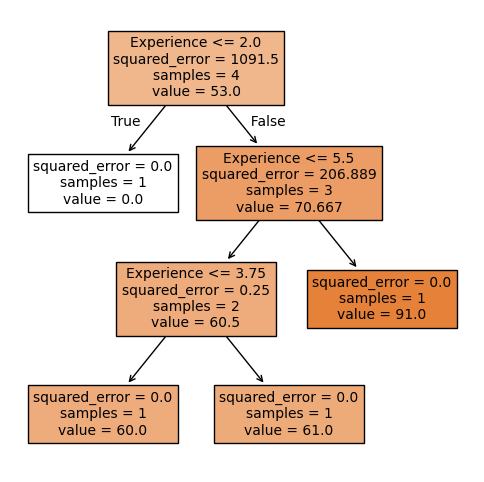

In [30]:
# Visualize
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
_ = tree.plot_tree(
    rf_regressor.estimators_[0],
    feature_names=['Experience'],
    filled=True
)